# Quark-Gluons jets

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/QG_jets_fp32_0.npz`. We use only 1 file to this exploration.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/19362155) 

A `float32` (single-precision) version of the quark and gluon jet dataset originally published by Komiske, Metodiev, and Thaler (Zenodo record 3164691). Only the 20-file subset without charm and bottom quark jets is included here. All simulation parameters and jet selection criteria are identical to the original:

- Pythia 8.226, $\sqrt{s} = 14 TeV$
- Quarks from `WeakBosonAndParton:qg2gmZq`, gluons from `WeakBosonAndParton:qqbar2gmZg` with the Z decaying to neutrinos
- FastJet 3.3.0, anti-k_t jets with $R = 0.4$
- $p_T^jet \in [500, 550] GeV, |y^jet| < 1.7$

There are 20 files, each in compressed NumPy format (`QG_jets_fp32_0.npz` through `QG_jets_fp32_19.npz`). Each file contains two arrays:

- **X**: (100000, M, 4) — 50k quark and 50k gluon jets, randomly sorted, padded to max multiplicity M, with particle features (pt, rapidity, azimuthal angle, pdgid) stored as float32
- **y**: (100000,) — jet labels, gluon = 0, quark = 1
The original dataset stores X in float64. Here X has been cast to float32, approximately halving file size. The y labels are unchanged.

Komiske, Metodiev, Thaler, Energy Flow Networks: Deep Sets for Particle Jets, JHEP 01 (2019) 121, arXiv:1810.05165

In [ ]:
# import libraries
import numpy as np

In [ ]:
try:
    with np.load('../data/raw/quark-gluon/QG_jets_fp32_0.npz', 'r') as f:
        print("File keys:", list(f.keys()), "\n")

        for key in f.keys():
            print(f"Shape of '{key}': {f[key].shape}")

        X = f['X'][:]
        y = f['y'][:]
except Exception as e:
    print(f"Error loading data using numpy: {e}")

File keys: ['X', 'y'] 

Shape of 'X': (100000, 139, 4)
Shape of 'y': (100000,)


Let's see what is inside

### Data exploration

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [ ]:
num_jets, max_multiplicity, num_features = X.shape

# Create jet IDs and labels for each particle
jet_ids = np.repeat(np.arange(num_jets), max_multiplicity)
labels = np.repeat(y, max_multiplicity)
# Flatten the 3D array to 2D for easier DataFrame creation
x_flat = X.reshape(-1, num_features)

# dataframe
df = pl.DataFrame(
    x_flat,
    schema=['pt', 'eta', 'phi', 'pdgid']
    ).with_columns([
    pl.Series('jet_id', jet_ids, dtype=pl.Int32),
    pl.Series('target', labels, dtype=pl.Int8)
])

df_reals = df.filter(pl.col('pt') > 0)

del num_features, num_jets, x_flat, labels, jet_ids#, max_multiplicity
gc.collect()

print(f"Total particles: {len(df)}")

Total particles: 13900000


After this first exploration we found a dataset with $100\ 000 \times 139 = 13\ 900\ 000$ particles in total.

In [ ]:
# statistics by label
stats = df_reals.group_by('target').agg([
    pl.len().alias('count'),
    pl.col('pt').mean().alias('mean_pt'),
    pl.col('pt').std().alias('std_pt'),
    pl.col('eta').mean().alias('mean_eta'),
    pl.col('eta').std().alias('std_eta'),
    pl.col('phi').mean().alias('mean_phi'),
    pl.col('phi').std().alias('std_phi')
])

print(stats)

shape: (2, 8)
┌────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────┐
│ target ┆ count   ┆ mean_pt  ┆ std_pt    ┆ mean_eta  ┆ std_eta  ┆ mean_phi ┆ std_phi │
│ ---    ┆ ---     ┆ ---      ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ i8     ┆ u32     ┆ f32      ┆ f32       ┆ f32       ┆ f32      ┆ f32      ┆ f32     │
╞════════╪═════════╪══════════╪═══════════╪═══════════╪══════════╪══════════╪═════════╡
│ 0      ┆ 2660906 ┆ 9.847878 ┆ 17.750917 ┆ 0.004918  ┆ 0.889108 ┆ 3.141987 ┆ 1.82073 │
│ 1      ┆ 1669999 ┆ 15.67758 ┆ 32.574562 ┆ -0.000791 ┆ 0.860042 ┆ 3.130167 ┆ 1.82093 │
└────────┴─────────┴──────────┴───────────┴───────────┴──────────┴──────────┴─────────┘


We can see some first diferences between gluons, 0; and quarks, 1. For example, the mean transversal momentum for quarks is greater and also the std. From the theory, we expect an isotropic distribution, thatis why mean eta is close to 0. Something interesting is that the mean phi is not close to 0, actually it is close to $\pi$, which is a bit strange. We will explore this later.

## Data visualization

In [ ]:
# style configuration
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "ytick.direction": "in",
    "xtick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 150,
    "figure.figsize": (10, 6),
    "text.usetex": False
})

Q_COLOR = "#1f77b4"
G_COLOR = "#ff7f0e"

### Global features

Now we will visualize the multiplicity

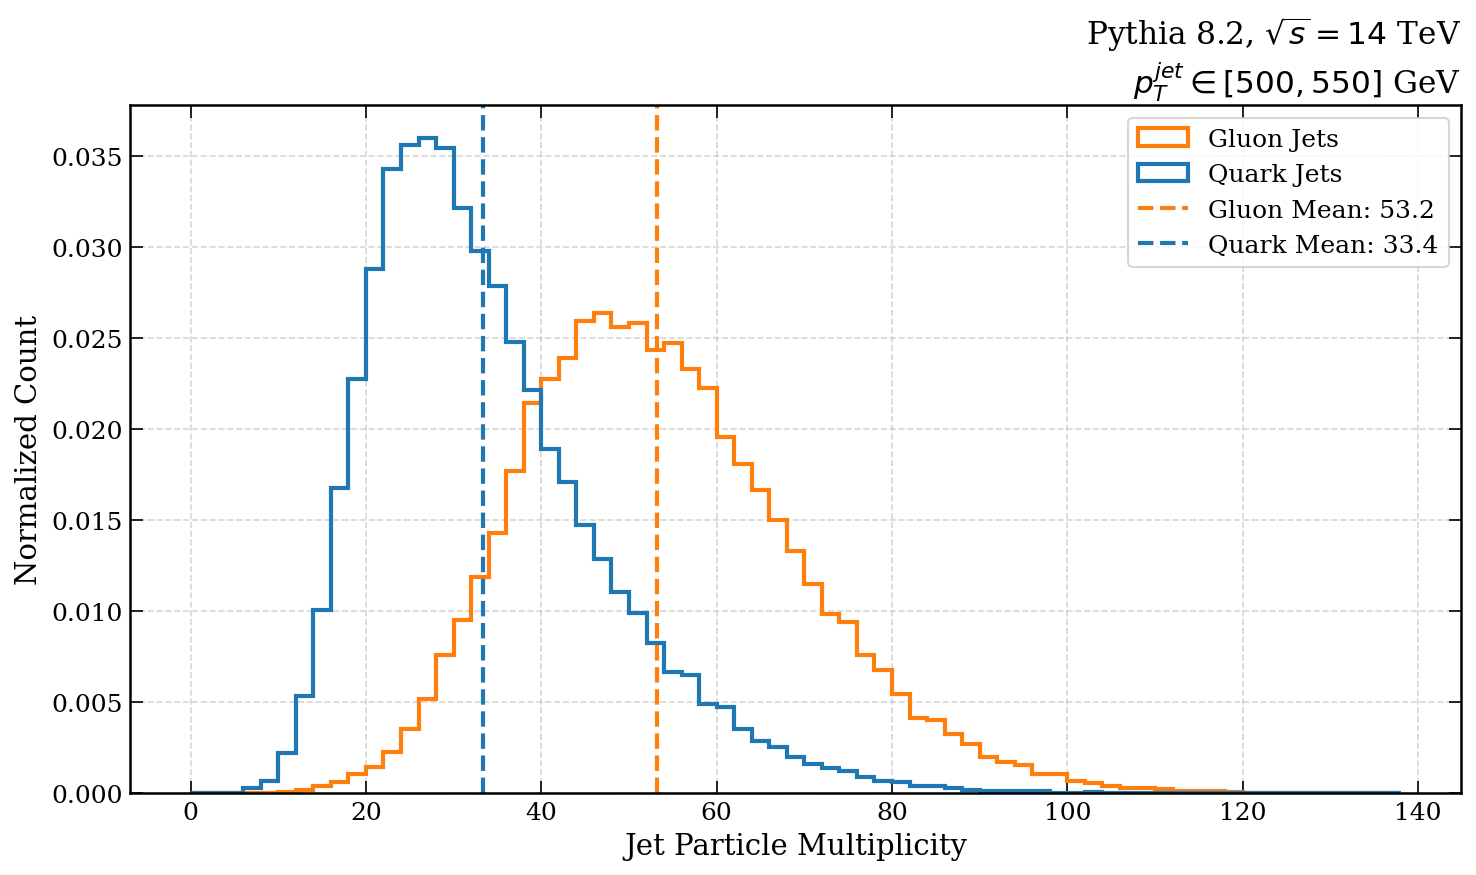

In [ ]:
# Histogram
df_mult = df_reals.group_by(['jet_id', "target"]).agg(pl.len().alias("multiplicity"))

mult_g = df_mult.filter(pl.col('target') == 0)['multiplicity'].to_numpy()
mult_q = df_mult.filter(pl.col('target') == 1)['multiplicity'].to_numpy()

plt.figure()
bins_mult = np.arange(0, max_multiplicity, 2)
plt.hist(mult_g, 
            bins=bins_mult,
            histtype="step",
            lw=2,
            #alpha=0.6,
            label='Gluon Jets',
            color=G_COLOR,
            density=True)
plt.hist(mult_q, 
            bins=bins_mult,
            histtype="step",
            lw=2,
            #alpha=0.6,
            label='Quark Jets',
            color=Q_COLOR,
            density=True)

plt.xlabel(r'Jet Particle Multiplicity')
plt.ylabel('Normalized Count')
#plt.xlim(0, 100)
# Vertical lines with the mean of each distribution
plt.axvline(mult_g.mean(), color=G_COLOR, linestyle='--', lw=2, label=f'Gluon Mean: {mult_g.mean():.1f}')
plt.axvline(mult_q.mean(), color=Q_COLOR, linestyle='--', lw=2, label=f'Quark Mean: {mult_q.mean():.1f}')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.title(r"Pythia 8.2, $\sqrt{s} = 14$ TeV" '\n' \
            r"$p_T^{jet} \in [500, 550]$ GeV",
            loc="right", fontsize=15)
plt.tight_layout()
plt.show()

In this plot we can see a little tail to the right in the Quark distribution, also with a lower dispersion than the Gluon distribution. This is consistent with the fact that Quark jets are more collimated than Gluon jets, which means that they have a smaller angular spread and therefore a lower multiplicity.

The range are pretty similar in both cases.

In [ ]:
df_pdg = pl.DataFrame({
    "pdgid": X[:, :, 3].reshape(-1),
    "target": y
}).filter(pl.col("pdgid") != 0) # Remove padding

# Official Particle Data Group (PDG) translation dictionary
pdg_labels = {
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
    111: r"$\pi^0$",
    22: r"$\gamma$",
    321: r"$K^+$",
    -321: r"$K^-$",
    2212: r"$p$",
    -2212: r"$\bar{p}$",
    11: r"$e^-$",
    -11: r"$e^+$",
    13: r"$\mu^-$",
    -13: r"$\mu^+$",
    2112: r"$n$",
    -2112: r"$\bar{n}$"
}

# Find the most abundant particles in the dataset dynamically
top_particles = (df_pdg.group_by("pdgid")
                 .len()
                 .sort("len", descending=True)
                 .head(8)["pdgid"]
                 .to_list())

# Group and calculate relative fractions by Jet type
df_counts = (df_pdg.filter(pl.col("pdgid").is_in(top_particles))
             .group_by(["target", "pdgid"])
             .len()
             .with_columns(
                 (pl.col("len") / pl.col("len").sum().over("target")).alias("fraction")
             ))

# ==========================================
# 2. RENDERING THE DISCRETE BAR CHART
# ==========================================
fig, ax = plt.subplots()

x_indexes = np.arange(len(top_particles))
bar_width = 0.35

# Extract the fractions in order to maintain consistency on the X-axis
frac_g = [df_counts.filter((pl.col("target") == 0) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]
frac_q = [df_counts.filter((pl.col("target") == 1) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]

# Draw the bars for Gluons and Quarks
ax.bar(x_indexes - bar_width/2, frac_g, bar_width, color=G_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Gluon Jets")
ax.bar(x_indexes + bar_width/2, frac_q, bar_width, color=Q_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Quark Jets")

# Map the names in LaTeX format on the X-axis
xtick_names = [pdg_labels.get(int(p), f"ID: {int(p)}") for p in top_particles]
ax.set_xticks(x_indexes)
ax.set_xticklabels(xtick_names, rotation=0)

ax.set_xlabel("Particle Identity (PDG Code)")
ax.set_ylabel("Relative Fraction per Jet Type")
ax.set_title("Jet Particle Composition (Hadronization Layer)", loc="left", fontweight="bold")
ax.grid(True, axis='y', linestyle="--", alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("jet_pdgid_composition.pdf", dpi=300)
plt.show()

del df_counts, df_pdg, top_particles, frac_g, frac_q, xtick_names
del df_mult, mult_g, mult_q
gc.collect()

NameError: name 'labels' is not defined

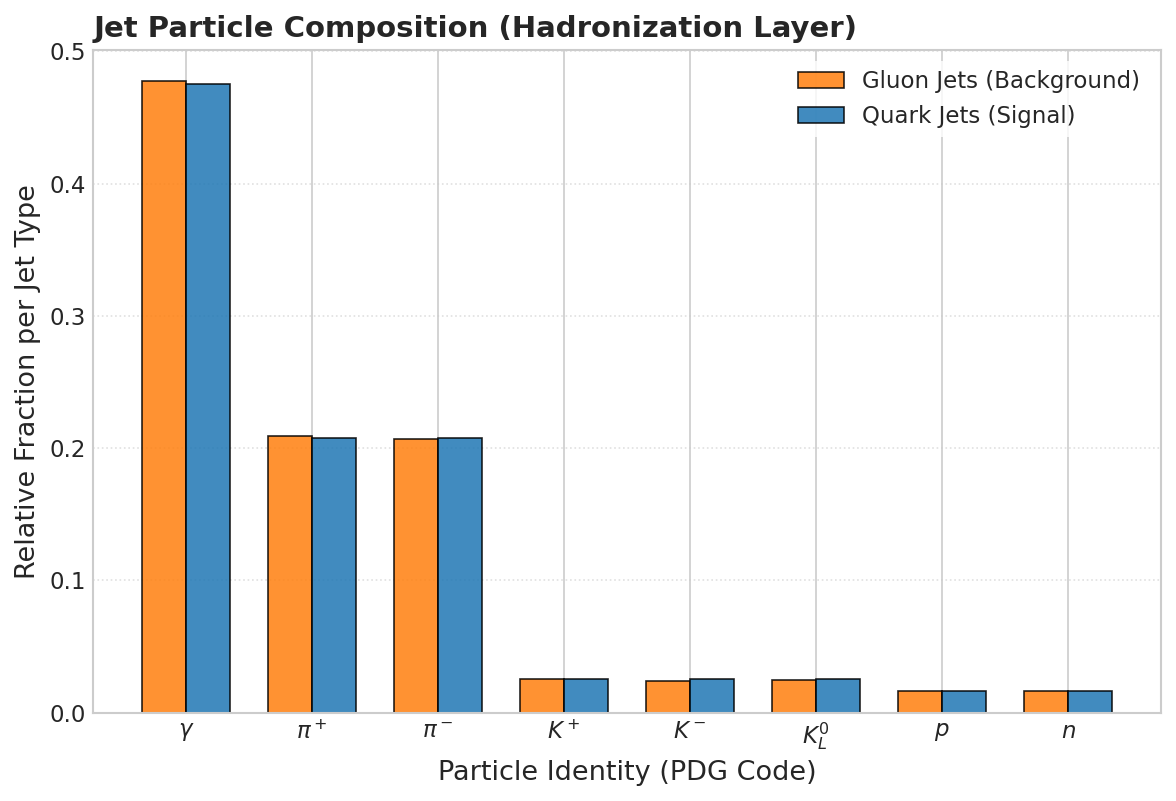

17332

In [ ]:
# ==============================================================================
# 1. PREPROCESAMIENTO VECTORIZADO CON POLARS
# ==============================================================================
num_jets, max_multiplicity, _ = X.shape

# Repetimos la etiqueta del jet 'y' para cada uno de sus constituyentes
labels_flat = np.repeat(y, max_multiplicity)
pdgid_flat = X[:, :, 3].reshape(-1)

# Crear el DataFrame inicial y remover el padding de ceros
df_pdg = pl.DataFrame(
    {"pdgid": pdgid_flat, "target": labels_flat}
).filter(pl.col("pdgid") != 0)

# Diccionario oficial del Particle Data Group (PDG) para renderizado LaTeX
pdg_labels = {
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
    111: r"$\pi^0$",
    22: r"$\gamma$",
    321: r"$K^+$",
    -321: r"$K^-$",
    2212: r"$p$",
    -2212: r"$\bar{p}$",
    11: r"$e^-$",
    -11: r"$e^+$",
    13: r"$\mu^-$",
    -13: r"$\mu^+$",
    2112: r"$n$",
    -2112: r"$\bar{n}$",
    130: r"$K_L^0$",
    310: r"$K_S^0$",
}

# Encontrar dinámicamente las 8 partículas más abundantes
top_particles = (
    df_pdg.group_by("pdgid")
    .len()
    .sort("len", descending=True)
    .head(8)["pdgid"]
    .to_list()
)

# Filtrar por el top 8 y calcular la fracción normalizada por tipo de Jet (target)
df_counts = (
    df_pdg.filter(pl.col("pdgid").is_in(top_particles))
    .group_by(["target", "pdgid"])
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("target")).alias("fraction")
    )
)

# Pivoteamos para alinear perfectamente quarks y gluones en columnas paralelas
# Esto evita por completo el uso de listas e IndexError
df_pivot = df_counts.pivot(
    on="target", index="pdgid", values="fraction"
).fill_null(0.0)

# Reordenar el dataframe pivotado para que coincida estrictamente con el orden de abundancia
df_pivot = df_pivot.filter(pl.col("pdgid").is_in(top_particles)).sort(
    pl.col("pdgid").map_elements(lambda p: top_particles.index(p), return_dtype=pl.Int64)
)

# Extraer los vectores finales listos para Matplotlib
frac_g = df_pivot.select(pl.nth(1)).to_numpy().flatten()  # target = 0 (Gluon)
frac_q = df_pivot.select(pl.nth(2)).to_numpy().flatten()  # target = 1 (Quark)

# ==============================================================================
# 2. RENDERIZADO DEL GRÁFICO DE BARRAS DISCRETAS
# ==============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8.0, 5.5))

x_indexes = np.arange(len(top_particles))
bar_width = 0.35

# Dibujar las barras estructuradas
ax.bar(
    x_indexes - bar_width / 2,
    frac_g,
    bar_width,
    color=G_COLOR,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8,
    label="Gluon Jets (Background)",
)
ax.bar(
    x_indexes + bar_width / 2,
    frac_q,
    bar_width,
    color=Q_COLOR,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8,
    label="Quark Jets (Signal)",
)

# Mapear los nombres en formato LaTeX en el eje X
xtick_names = [pdg_labels.get(int(p), f"ID: {int(p)}") for p in top_particles]
ax.set_xticks(x_indexes)
ax.set_xticklabels(xtick_names, rotation=0, fontsize=12)

ax.set_xlabel("Particle Identity (PDG Code)", fontsize=13)
ax.set_ylabel("Relative Fraction per Jet Type", fontsize=13)
ax.set_title(
    "Jet Particle Composition (Hadronization Layer)",
    loc="left",
    fontweight="bold",
    fontsize=14,
)

# Detalles de formato estilo revista científica
ax.tick_params(direction="in", top=False, right=True, labelsize=11)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

plt.tight_layout()
plt.show()

# Limpieza estricta de memoria
del df_pdg, df_counts, df_pivot, labels_flat, pdgid_flat
gc.collect()

### Local features

For local features we will explore the distribution of the transverse momentum. Pseudorapidity, and azimuthal angle for both quark and gluon jets are expected to be similar, but we will see if there are any differences in the distributions.

In [ ]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

/home/jorgetoral/Documents/GSoC-26/Quantum-Sinusoidal-Kolmogorov-Arnold-Networks-for-High-Energy-Physics/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/jorgetoral/Documents/GSoC-26/Quantum-Sinusoidal-Kolmogorov-Arnold-Networks-for-High-Energy-Physics/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/jorgetoral/Documents/GSoC-26/Quantum-Sinusoidal-Kolmogorov-Arnold-Networks-for-High-Energy-Physics/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: U

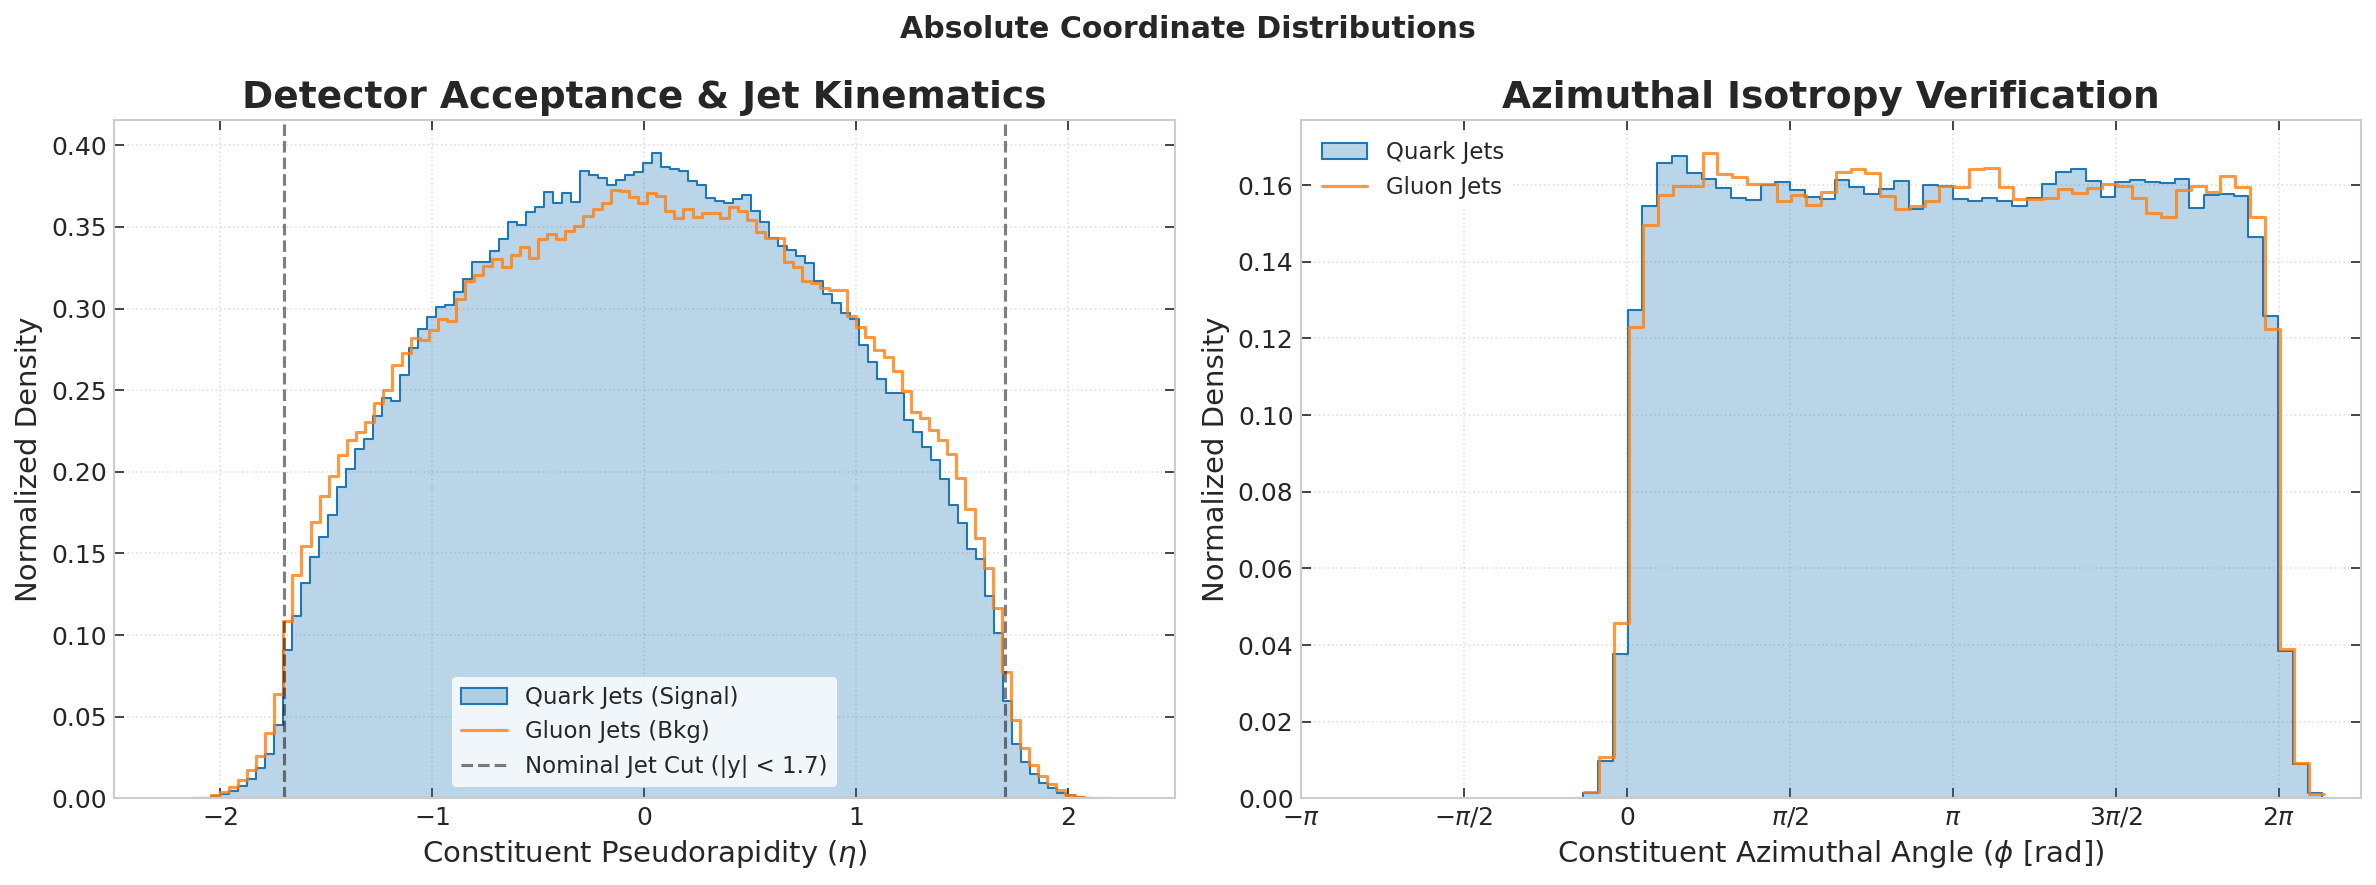

11463

In [ ]:
# 1. Configuración de estilo profesional (Estilo High-Energy Physics / Seaborn)
plt.style.use("seaborn-v0_8-whitegrid")

# 2. Separar los constituyentes reales por clase para la comparación
# Evitamos copiar todo el DataFrame, solo seleccionamos la columna necesaria
quarks_particles = df_reals.filter(pl.col("target") == 1)
gluons_particles = df_reals.filter(pl.col("target") == 0)

# 3. Inicializar el Canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores consistente (Azul para Quarks / Naranja-Rojo para Gluones)
#colors = {"quark": "#1f77b4", "gluon": "#e377c2"}

# --- Subplot 1: Distribución de Pseudorapidez (eta) ---
ax0 = axes[0]
sns.histplot(
    data=quarks_particles,
    x="eta",
    stat="density",
    bins=100,
    color=Q_COLOR,
    element="step",
    fill=True,
    alpha=0.3,
    label="Quark Jets (Signal)",
    ax=ax0,
)
sns.histplot(
    data=gluons_particles,
    x="eta",
    stat="density",
    bins=100,
    color=G_COLOR,
    element="step",
    fill=False,
    alpha=0.8,
    label="Gluon Jets (Bkg)",
    ax=ax0,
)

ax0.set_title("Detector Acceptance & Jet Kinematics", fontweight="bold")
ax0.set_xlabel(r"Constituent Pseudorapidity ($\eta$)", fontsize=14)
ax0.set_ylabel("Normalized Density", fontsize=14)
ax0.set_xlim([-2.5, 2.5])  # Un poco más allá del corte nominal de |y| < 1.7
ax0.axvline(
    1.7, color="black", linestyle="--", alpha=0.5, label="Nominal Jet Cut (|y| < 1.7)"
)
ax0.axvline(-1.7, color="black", linestyle="--", alpha=0.5)
ax0.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

# --- Subplot 2: Distribución del Ángulo Azimutal (phi) ---
ax1 = axes[1]
sns.histplot(
    data=quarks_particles,
    x="phi",
    stat="density",
    bins=50,
    color=Q_COLOR,
    element="step",
    fill=True,
    alpha=0.3,
    label="Quark Jets",
    ax=ax1,
)
sns.histplot(
    data=gluons_particles,
    x="phi",
    stat="density",
    bins=50,
    color=G_COLOR,
    element="step",
    fill=False,
    alpha=0.8,
    label="Gluon Jets",
    ax=ax1,
)

ax1.set_title("Azimuthal Isotropy Verification", fontweight="bold")
ax1.set_xlabel(r"Constituent Azimuthal Angle ($\phi$ [rad])", fontsize=14)
ax1.set_ylabel("Normalized Density", fontsize=14)
#ax1.set_xlim([-np.pi - 0.2, np.pi + 0.2])
ax1.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax1.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

# --- Detalles de formato global ---
for ax in axes:
    ax.tick_params(direction="in", top=True, right=True, length=5)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(
    "Absolute Coordinate Distributions",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# 4. Limpieza estricta de memoria ram
del quarks_particles, gluons_particles
gc.collect()

Now we can see why the mean value of $\phi$ is close to $\pi$, because the range of $\phi$ is from $0$ to $2\pi$, and the distribution is symmetric around $\pi$. The distribution of $\phi$ and $\eta$ are similar for both quark and gluon jets, this confirms that the jets are isotropic, as expected.

Let's calculate the center of each jet and see the dispersión in the $\phi vs \eta$ space.

In [ ]:
# 1. Calculate the pT-weighted center for each jet
jet_centers = df_reals.group_by("jet_id").agg(
    [
        ((pl.col("eta") * pl.col("pt")).sum()
        / pl.col("pt").sum()).alias("jet_eta"),
        ((pl.col("phi") * pl.col("pt")).sum()
        / pl.col("pt").sum()).alias("jet_phi"),
    ]
)

# 2. Join the jet centers back to the dataframe of charged particles
df_relatives = df_reals.join(jet_centers, on="jet_id")

# 3. Calculate the relative deltas
# Note: For delta_phi, we need to ensure the periodicity of the detector cylinder [-pi, pi]
df_relatives = df_relatives.with_columns(
    [
        (pl.col("eta") - pl.col("jet_eta")).alias("delta_eta"),
        # Angular correction to avoid jumps at the phi boundaries
        (
            (pl.col("phi") - pl.col("jet_phi") + np.pi) % (2 * np.pi) - np.pi
        ).alias("delta_phi"),
    ]
)

del jet_centers
gc.collect()

24995

In [ ]:
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

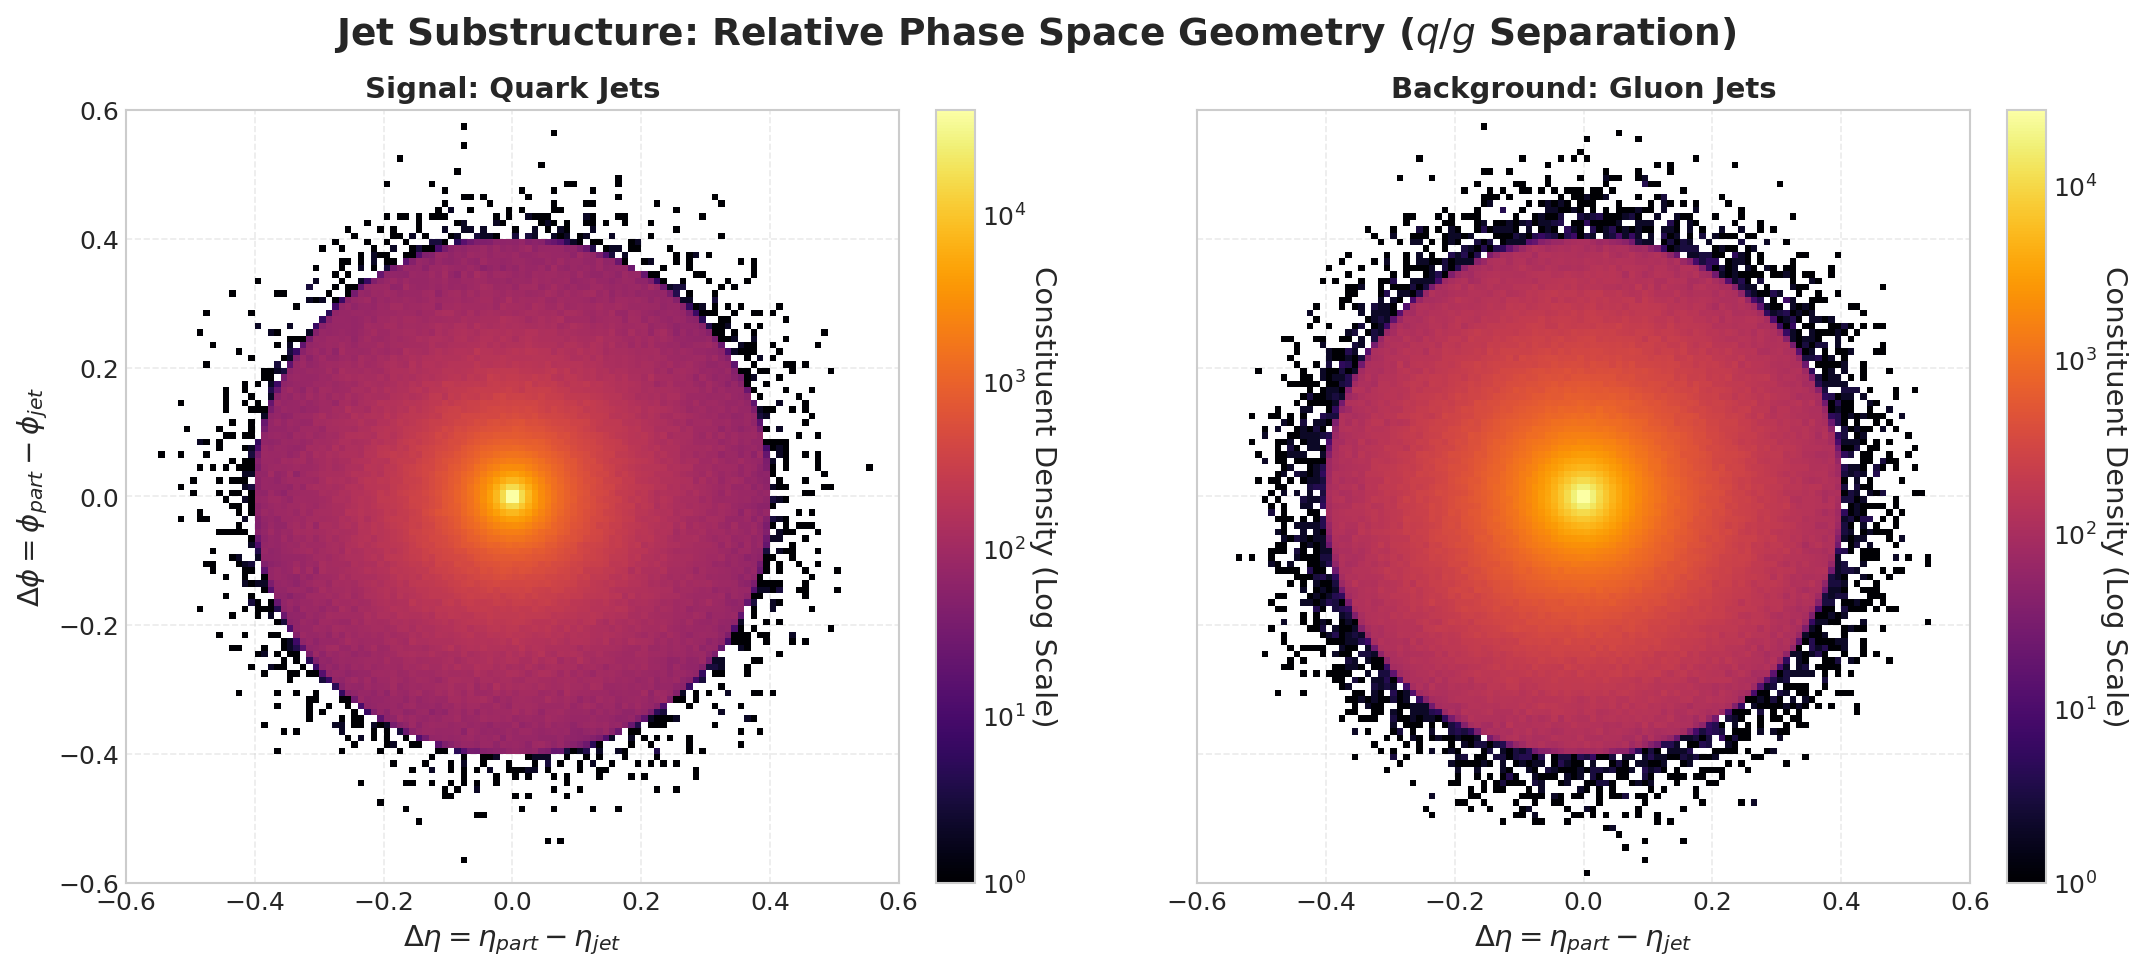

24419

In [ ]:
# Separate the deltas by class for the 2D histogram
quarks_df = df_relatives.filter(pl.col("target") == 1)
gluons_df = df_relatives.filter(pl.col("target") == 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)

# Adjust the range to the actual jet size (R = 0.4) plus a small margin
img_range = [[-0.6, 0.6], [-0.6, 0.6]]
bin_resolution = 120

# --- Panel 1: Quarks (Signal) ---
im0 = axes[0].hist2d(
    quarks_df["delta_eta"].to_numpy(),
    quarks_df["delta_phi"].to_numpy(),
    bins=bin_resolution,
    range=img_range,
    cmap="inferno",
    norm=LogNorm(),
)
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Constituent Density (Log Scale)", rotation=270, labelpad=15)
axes[0].set_title(
    "Signal: Quark Jets", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel(r"$\Delta \eta = \eta_{part} - \eta_{jet}$", fontsize=14)
axes[0].set_ylabel(r"$\Delta \phi = \phi_{part} - \phi_{jet}$", fontsize=14)

# --- Panel 2: Gluons (Background) ---
im1 = axes[1].hist2d(
    gluons_df["delta_eta"].to_numpy(),
    gluons_df["delta_phi"].to_numpy(),
    bins=bin_resolution,
    range=img_range,
    cmap="inferno",
    norm=LogNorm(),
)
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Constituent Density (Log Scale)", rotation=270, labelpad=15)
axes[1].set_title(
    "Background: Gluon Jets", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel(r"$\Delta \eta = \eta_{part} - \eta_{jet}$", fontsize=14)

# Strict formatting for both panels
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction="in", top=True, right=True)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    "Jet Substructure: Relative Phase Space Geometry ($q/g$ Separation)",
    fontsize=18,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

del quarks_df, gluons_df
gc.collect()

in the plot we can see an aparent difference. The quark jets are more concentrated in the center, while the gluon jets are more spread out. This is consistent with the fact that quark jets are more collimated than gluon jets, which means that they have a smaller angular spread and therefore a lower multiplicity.

Now, we are going to focus on the pt. We will order the particles by pt and see where the distribution completes the 80 % of the total pt. This will give us an idea of how the pt is distributed among the particles in the jet, and also a decision boundary to select the particles that contribute the most to the jet pt. We will see if there are any differences between quark and gluon jets in this regard.

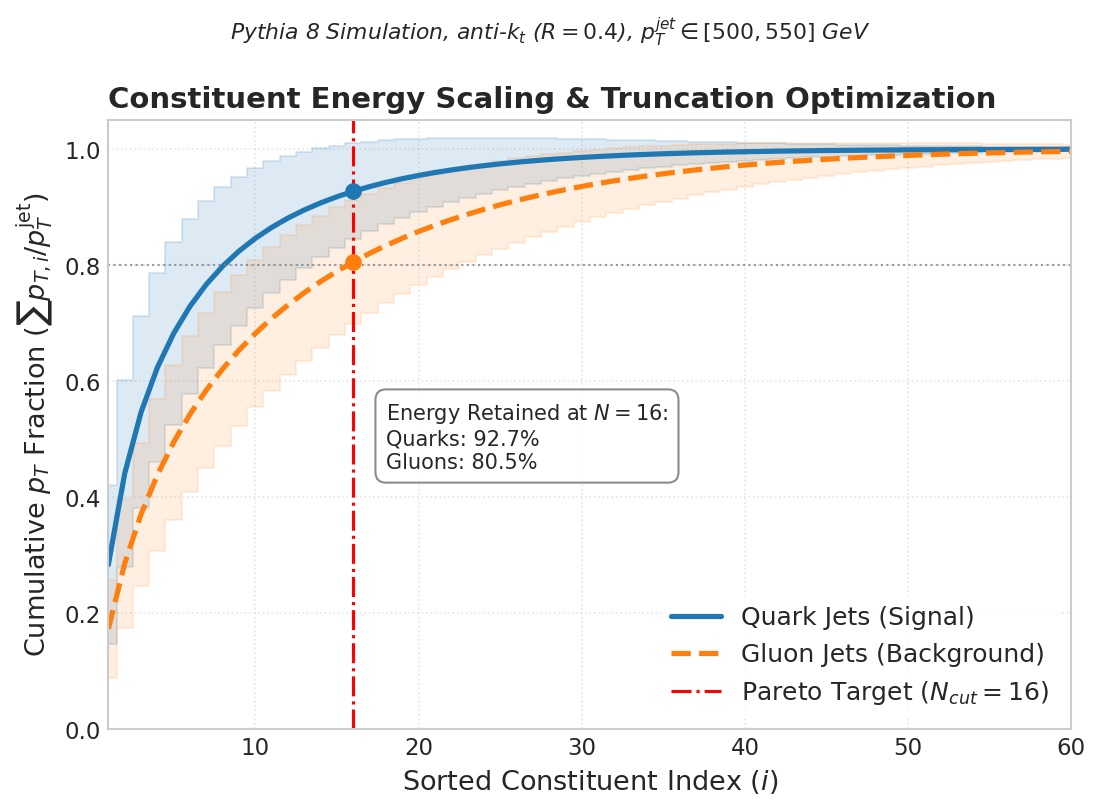

2212

In [ ]:
# ==============================================================================
# 1. pt sorting
# ==============================================================================
# Extract the pT component (100000, 139)
pt_matrix = X[:, :, 0]

# np.argsort gives indices from smallest to largest. With [:, ::-1] we invert to descending
sort_indices = np.argsort(pt_matrix, axis=1)[:, ::-1]

# Reorder the original X matrix in its 4 features using advanced indexing
# np.arange(X.shape[0])[:, None] ensures that each jet keeps its own particles
X_sorted = X[np.arange(X.shape[0])[:, None], sort_indices, :]

# Extract the sorted pT block for Pareto analysis
pt_block = X_sorted[:, :, 0]

# ==============================================================================
# 2. PARETO KINEMATIC PROCESSING
# ==============================================================================
# Cumulative sum along the particle index (column axis)
cumulative_pt = np.cumsum(pt_block, axis=1)

# The last cumulative element (index -1) represents the total recovered pT of the Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt)  # Avoid division by zero

# Convert to cumulative fractions (scale from 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate profiles using the true labels 'y' (0: gluon, 1: quark)
quark_profiles = pt_fraction_matrix[y == 1]
gluon_profiles = pt_fraction_matrix[y == 0]

# Calculate the mean and standard deviation for each step of the sequence
mean_quark = np.mean(quark_profiles, axis=0)
std_quark = np.std(quark_profiles, axis=0)

mean_gluon = np.mean(gluon_profiles, axis=0)
std_gluon = np.std(gluon_profiles, axis=0)

# The X axis will go from particle 1 to the maximum (139)
max_particles = X.shape[1]
particle_indices = np.arange(1, max_particles + 1)

# ==============================================================================
# 3. AUTOMATIC TRUNCATION CALCULATION (80% THRESHOLD)
# ==============================================================================
# Find the first index where BOTH curves exceed 80% (0.80)
both_exceed_80 = (mean_quark >= 0.80) & (mean_gluon >= 0.80)

if np.any(both_exceed_80):
    N_cut = int(np.where(both_exceed_80)[0][0] + 1)
else:
    N_cut = max_particles

cut_fraction_quark = mean_quark[N_cut - 1]
cut_fraction_gluon = mean_gluon[N_cut - 1]

# ==============================================================================
# 4. PLOT CONSTRUCTION AND RENDERING (Publication Style)
# ==============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Consistent color definitions
#QUARK_COLOR = "#1f77b4"  # Blue for signal
#GLUON_COLOR = "#e377c2"  # Pink/Mint for background

# Signal Curve (Quarks) with its uncertainty band
ax.plot(
    particle_indices,
    mean_quark,
    color=Q_COLOR,
    lw=2.5,
    label=r"Quark Jets (Signal)",
)
ax.fill_between(
    particle_indices,
    mean_quark - std_quark,
    mean_quark + std_quark,
    color=Q_COLOR,
    alpha=0.15,
    step="mid",
)

# Background Curve (Gluons) with its uncertainty band
ax.plot(
    particle_indices,
    mean_gluon,
    color=G_COLOR,
    lw=2.5,
    label="Gluon Jets (Background)",
    linestyle="--",
)
ax.fill_between(
    particle_indices,
    mean_gluon - std_gluon,
    mean_gluon + std_gluon,
    color=G_COLOR,
    alpha=0.12,
    step="mid",
)

# --- TRUNCATION THRESHOLD INDICATORS ---
ax.axhline(y=0.80, color="gray", linestyle=":", lw=1.0, alpha=0.8)
ax.axvline(
    x=N_cut,
    color="red",
    linestyle="-.",
    lw=1.5,
    label=f"Pareto Target ($N_{{cut}}={N_cut}$)",
)

ax.plot(N_cut, cut_fraction_quark, marker="o", color=Q_COLOR, markersize=7)
ax.plot(N_cut, cut_fraction_gluon, marker="o", color=G_COLOR, markersize=7)

# Explanatory text box with the actual retained percentages
physics_text = (
    f"Energy Retained at $N={N_cut}$:\n"
    f"Quarks: {cut_fraction_quark*100:.1f}%\n"
    f"Gluons: {cut_fraction_gluon*100:.1f}%"
)
ax.text(
    N_cut + 2,
    0.45,
    physics_text,
    fontsize=10,
    bbox=dict(
        facecolor="white", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.5"
    ),
)

# --- AXIS FORMATTING ---
ax.set_xlabel("Sorted Constituent Index ($i$)", fontsize=13)
ax.set_ylabel(
    r"Cumulative $p_T$ Fraction ($\sum p_{T,i} / p_{T}^{\mathrm{jet}}$)",
    fontsize=13
)
ax.set_xlim(1, 60)
ax.set_ylim(0.0, 1.05)

ax.tick_params(direction="in", top=True, right=True, labelsize=11)
ax.set_title(
    "Constituent Energy Scaling & Truncation Optimization",
    loc="left",
    fontweight="bold",
    fontsize=14
)
fig.suptitle(
    r"Pythia 8 Simulation, anti-$k_t$ ($R=0.4$), $p_T^{jet} \in [500, 550]$ GeV",
    fontsize=10.5,
    y=0.98,
    style="italic"
)

ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(frameon=True, facecolor="white", edgecolor="none", loc="lower right")

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. MEMORY CLEANUP
# ==============================================================================
del (
    cumulative_pt,
    total_pt,
    total_pt_safe,
    pt_fraction_matrix,
    quark_profiles,
    gluon_profiles,
)
del mean_quark, std_quark, mean_gluon, std_gluon, particle_indices, sort_indices
gc.collect()

This plot shows the cumulative distribution of the transverse momentum for both quark and gluon jets. We can see that the quark jets have a steeper slope, which means that they have a higher fraction of their total pt concentrated in the first few particles. This is consistent with the fact that quark jets are more collimated than gluon jets, which means that they have a smaller angular spread and therefore a lower multiplicity.

Other conclusion from this plot is the point where the cumulative distribution reaches 80 % of the total pt. To mantain the dimensionality of the input data, we will select the first 15 particles, which is a good compromise between retaining most of the pt and reducing the number of particles. This will also help to reduce the computational cost of training the model.

In [ ]:
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import pandas as pd

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3863/310171641.py:47: SyntaxWarning: invalid escape sequence '\m'
  label=f"Quark Jets ($\mu={mean_q:.1f}$)",
/tmp/ipykernel_3863/310171641.py:56: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gluon Jets ($\mu={mean_g:.1f}$)",
/tmp/ipykernel_3863/310171641.py:190: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(["Quark\n(Signal)", "Gluon\n(Bkg)"], fontsize=11)


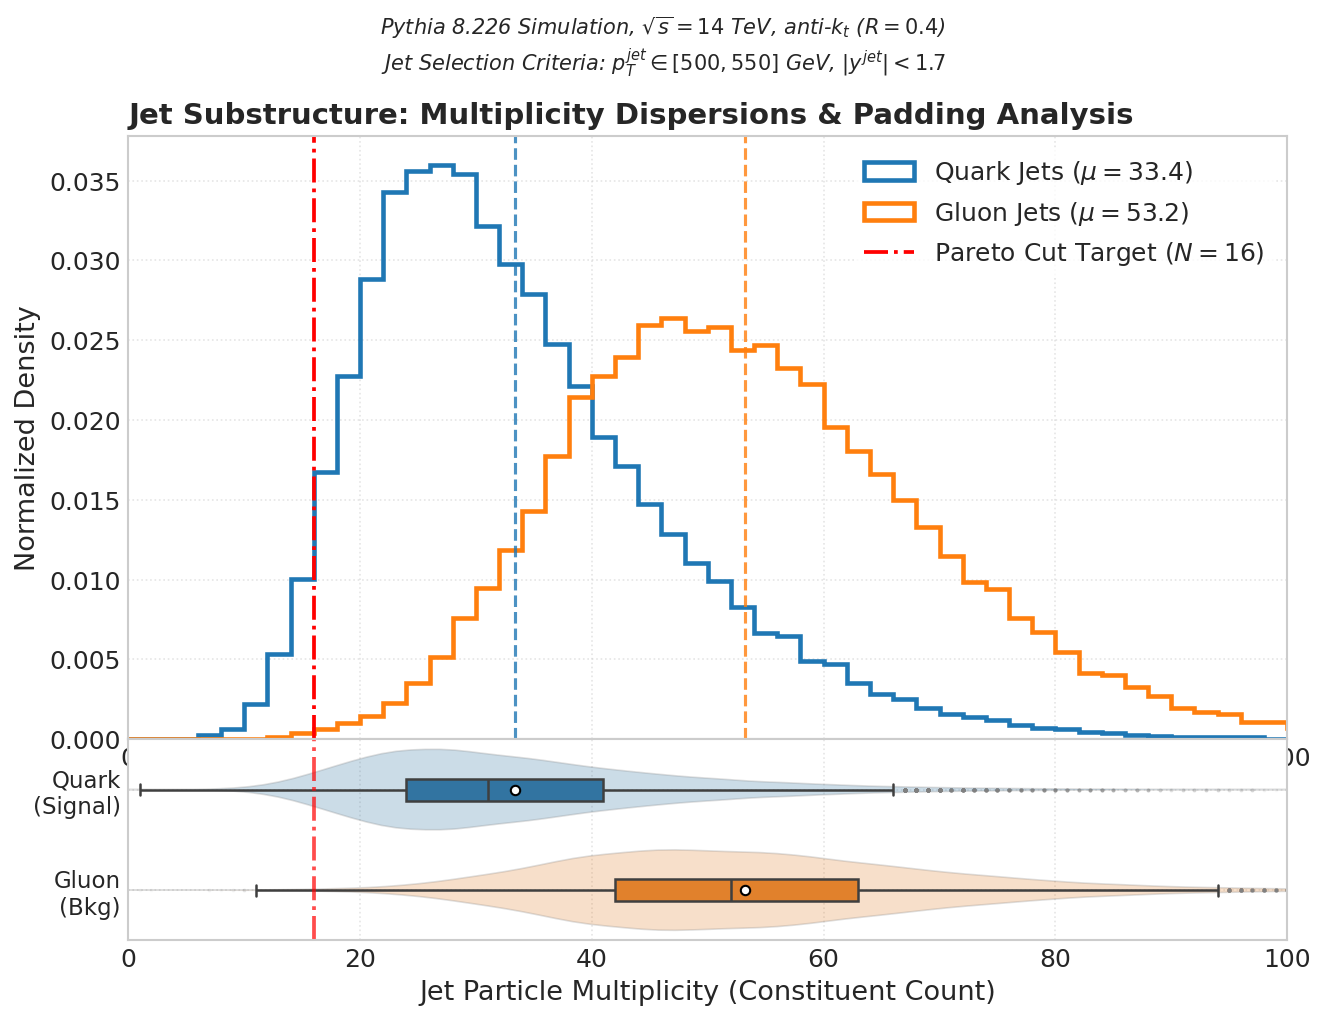

10022

In [ ]:
# ==============================================================================
# 1. EXTRACCIÓN DE DATOS Y ESTADÍSTICA DESCRIPTIVA CON POLARS
# ==============================================================================
# Calcular la multiplicidad real por jet (con pt > 0)
df_mult = df_reals.group_by(["jet_id", "target"]).agg(
    pl.len().alias("multiplicity")
)

# Separar en arrays de NumPy por clase
mult_q = df_mult.filter(pl.col("target") == 1)["multiplicity"].to_numpy()
mult_g = df_mult.filter(pl.col("target") == 0)["multiplicity"].to_numpy()

# Extracción de métricas clave para la inyección de texto y marcas
min_q, max_q = mult_q.min(), mult_q.max()
min_g, max_g = mult_g.min(), mult_g.max()
mean_q, median_q = mult_q.mean(), np.median(mult_q)
mean_g, median_g = mult_g.mean(), np.median(mult_g)

# ==============================================================================
# 2. CONFIGURACIÓN DEL CANVAS HÍBRIDO (GridSpec)
# ==============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(9.0, 7.0))

# Definición de las proporciones: 3 partes para histograma, 1 para boxplot
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.00)

ax_hist = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharex=ax_hist)

# Paleta de colores consistente
#Q_COLOR = "#1f77b4"  # Azul (Signal - Quark)
#G_COLOR = "#e377c2"  # Rosa/Menta (Background - Gluon)

# ==============================================================================
# 3. PANEL SUPERIOR: HISTOGRAMAS DE PASOS (STEP)
# ==============================================================================
bins_mult = np.arange(0, max_multiplicity + 2, 2)

ax_hist.hist(
    mult_q,
    bins=bins_mult,
    histtype="step",
    lw=2.2,
    color=Q_COLOR,
    density=True,
    label=f"Quark Jets ($\mu={mean_q:.1f}$)",
)
ax_hist.hist(
    mult_g,
    bins=bins_mult,
    histtype="step",
    lw=2.2,
    color=G_COLOR,
    density=True,
    label=f"Gluon Jets ($\mu={mean_g:.1f}$)",
)

# Líneas de las medias
ax_hist.axvline(mean_q, color=Q_COLOR, linestyle="--", lw=1.5, alpha=0.8)
ax_hist.axvline(mean_g, color=G_COLOR, linestyle="--", lw=1.5, alpha=0.8)

# LÍNEA CRUCIAL: Tu propuesta de corte N = 16
N_propuesto = 16
ax_hist.axvline(
    N_propuesto,
    color="red",
    linestyle="-.",
    lw=1.8,
    label=f"Pareto Cut Target ($N={N_propuesto}$)",
)

# Formato del panel superior
ax_hist.set_ylabel("Normalized Density", fontsize=13)
ax_hist.set_title(
    "Jet Substructure: Multiplicity Dispersions & Padding Analysis",
    loc="left",
    fontweight="bold",
    fontsize=14,
)
ax_hist.legend(frameon=True, facecolor="white", edgecolor="none", loc="upper right")
ax_hist.grid(True, linestyle=":", alpha=0.5)

# ==============================================================================
# 4. PANEL INFERIOR: BOXPLOTS Y VIOLINPLOTS HORIZONTALES HÍBRIDOS
# ==============================================================================
# Preparar DataFrame para Seaborn
df_box = pd.DataFrame(
    {
        "Multiplicity": np.concatenate([mult_q, mult_g]),
        "Class": ["Quark (Signal)"] * len(mult_q) + ["Gluon (Bkg)"] * len(mult_g),
    }
)

# Capa de Violín (Densidad suavizada de fondo)
sns.violinplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[Q_COLOR, G_COLOR],
    orient="h",
    inner=None,
    bw_method="silverman",
    linewidth=0.8,
    edgecolor="gray",
    alpha=0.25,
    ax=ax_box,
)

# Capa de Boxplot Estrecho (Cuartiles exactos)
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": 4.5,
}
flierprops = dict(marker=".", markersize=1.5, alpha=0.05, markeredgecolor="gray")

sns.boxplot(
    x="Multiplicity",
    y="Class",
    data=df_box,
    hue="Class",
    legend=False,
    palette=[Q_COLOR, G_COLOR],
    orient="h",
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    width=0.22,
    linewidth=1.2,
    ax=ax_box,
)
'''
# --- MARCAS DE MÍNIMOS Y MÁXIMOS ABSOLUTOS ---
# Posición 0 en Y es Quarks, Posición 1 en Y es Gluones
# Quarks Extremos
ax_box.plot(min_q, 0, marker="$]$", color="black", markersize=8, mew=2)
ax_box.plot(max_q, 0, marker="$[$", color="black", markersize=8, mew=2)
ax_box.text(
    min_q - 1,
    -0.18,
    f"Min: {min_q}",
    fontsize=8.5,
    fontweight="bold",
    ha="right",
    color=Q_COLOR,
)
ax_box.text(
    max_q + 1,
    -0.18,
    f"Max: {max_q}",
    fontsize=8.5,
    fontweight="bold",
    ha="left",
    color=Q_COLOR,
)

# Gluones Extremos
ax_box.plot(min_g, 1, marker="$]$", color="black", markersize=8, mew=2)
ax_box.plot(max_g, 1, marker="$[$", color="black", markersize=8, mew=2)
ax_box.text(
    min_g - 1,
    1.22,
    f"Min: {min_g}",
    fontsize=8.5,
    fontweight="bold",
    ha="right",
    color=G_COLOR,
)
ax_box.text(
    max_g + 1,
    1.22,
    f"Max: {max_g}",
    fontsize=8.5,
    fontweight="bold",
    ha="left",
    color=G_COLOR,
)
'''

# Replicar la línea de N=16 en el boxplot para ver el choque visual con las cajas
ax_box.axvline(N_propuesto, color="red", linestyle="-.", lw=1.8, alpha=0.7)

# Formato del panel inferior
ax_box.set_xlabel("Jet Particle Multiplicity (Constituent Count)", fontsize=13)
ax_box.set_ylabel("")
ax_box.set_yticklabels(["Quark\n(Signal)", "Gluon\n(Bkg)"], fontsize=11)
ax_box.set_xlim(0, 100)  # Enfocado para ver la física, omitiendo outliers extremos aislados
ax_box.grid(True, linestyle=":", alpha=0.5)

# --- METADATOS ESTILO HEP ---
fig.suptitle(
    r"Pythia 8.226 Simulation, $\sqrt{s} = 14$ TeV, anti-$k_t$ ($R=0.4$)"
    "\n"
    r"Jet Selection Criteria: $p_T^{jet} \in [500, 550]$ GeV, $|y^{jet}| < 1.7$",
    fontsize=10,
    y=0.97,
    style="italic",
    ha="center",
)

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. LIMPIEZA DE MEMORIA RAM
# ==============================================================================
del df_mult, df_box, mult_q, mult_g
gc.collect()

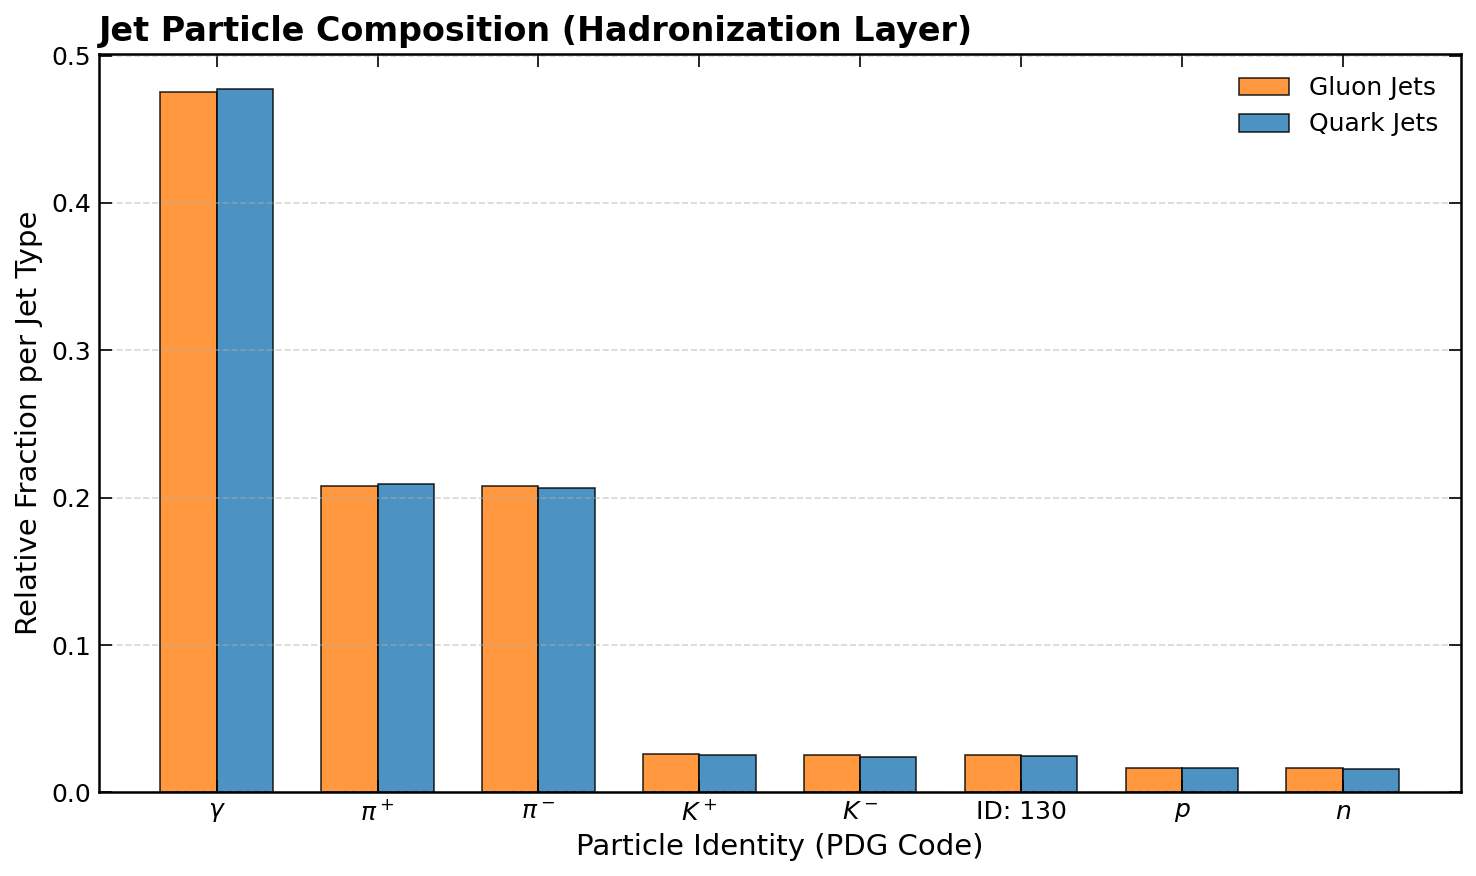

In [ ]:
df_pdg = pl.DataFrame({
    "pdgid": X[:, :, 3].reshape(-1),
    "target": labels
}).filter(pl.col("pdgid") != 0) # Remove padding

# Official Particle Data Group (PDG) translation dictionary
pdg_labels = {
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
    111: r"$\pi^0$",
    22: r"$\gamma$",
    321: r"$K^+$",
    -321: r"$K^-$",
    2212: r"$p$",
    -2212: r"$\bar{p}$",
    11: r"$e^-$",
    -11: r"$e^+$",
    13: r"$\mu^-$",
    -13: r"$\mu^+$",
    2112: r"$n$",
    -2112: r"$\bar{n}$"
}

# Find the most abundant particles in the dataset dynamically
top_particles = (df_pdg.group_by("pdgid")
                 .len()
                 .sort("len", descending=True)
                 .head(8)["pdgid"]
                 .to_list())

# Group and calculate relative fractions by Jet type
df_counts = (df_pdg.filter(pl.col("pdgid").is_in(top_particles))
             .group_by(["target", "pdgid"])
             .len()
             .with_columns(
                 (pl.col("len") / pl.col("len").sum().over("target")).alias("fraction")
             ))

# ==========================================
# 2. RENDERING THE DISCRETE BAR CHART
# ==========================================
fig, ax = plt.subplots()

x_indexes = np.arange(len(top_particles))
bar_width = 0.35

# Extract the fractions in order to maintain consistency on the X-axis
frac_g = [df_counts.filter((pl.col("target") == 0) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]
frac_q = [df_counts.filter((pl.col("target") == 1) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]

# Draw the bars for Gluons and Quarks
ax.bar(x_indexes - bar_width/2, frac_g, bar_width, color=G_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Gluon Jets")
ax.bar(x_indexes + bar_width/2, frac_q, bar_width, color=Q_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Quark Jets")

# Map the names in LaTeX format on the X-axis
xtick_names = [pdg_labels.get(int(p), f"ID: {int(p)}") for p in top_particles]
ax.set_xticks(x_indexes)
ax.set_xticklabels(xtick_names, rotation=0)

ax.set_xlabel("Particle Identity (PDG Code)")
ax.set_ylabel("Relative Fraction per Jet Type")
ax.set_title("Jet Particle Composition (Hadronization Layer)", loc="left", fontweight="bold")
ax.grid(True, axis='y', linestyle="--", alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("jet_pdgid_composition.pdf", dpi=300)
plt.show()